# **IMPORTING LIBRARIES**

In [1]:
# ==============================
# IMPORT LIBRARIES
# ==============================

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)

print("Libraries Imported Successfully")

Libraries Imported Successfully


# **UPLOAD DATASET**

In [4]:
from google.colab import files

uploaded = files.upload()

Saving part_1_ecommerce_customer_segmentation.xlsx to part_1_ecommerce_customer_segmentation.xlsx


In [5]:
df = pd.read_excel('part_1_ecommerce_customer_segmentation.xlsx')

# **UNDERSTANDING THE DATA**

In [6]:
# First 5 rows
df.head()

,InvoiceNo,StockCode,Description,Category,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,INV500000,P1022,Dark Chocolate Box,Grocery,1,2025-01-19 17:04:00,468.04,C10555,EIRE
1,INV500000,P1030,Sports Socks Pack,Apparel,1,2025-01-19 17:04:00,248.30,C10555,EIRE
2,INV500001,P1006,Wireless Mouse,Electronics,5,2025-10-17 18:50:00,729.12,C10422,India
3,INV500002,P1010,Protein Shaker,Fitness,2,2025-01-05 22:51:00,329.60,C10262,Netherlands
4,INV500002,P1022,Dark Chocolate Box,Grocery,1,2025-01-05 22:51:00,526.21,C10262,Netherlands


In [7]:
# Shape of dataset: Total rows and columns
df.shape

(4395, 9)

In [8]:
# View Column names
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Category', 'Quantity',
       'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [9]:
# Information about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4395 entries, 0 to 4394
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    4395 non-null   object        
 1   StockCode    4395 non-null   object        
 2   Description  4328 non-null   object        
 3   Category     4395 non-null   object        
 4   Quantity     4395 non-null   int64         
 5   InvoiceDate  4395 non-null   datetime64[ns]
 6   UnitPrice    4395 non-null   float64       
 7   CustomerID   4187 non-null   object        
 8   Country      4395 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 309.2+ KB


In [10]:
# Statistical summary
df.describe()

,Quantity,InvoiceDate,UnitPrice
count,4395.000000,4395,4395.000000
mean,2.826394,2025-06-13 22:25:17.597269504,747.081477
min,-50.000000,2025-01-02 14:47:00,-2244.520000
25%,1.000000,2025-03-20 14:25:00,328.200000
50%,2.000000,2025-06-14 15:03:00,544.320000
75%,4.000000,2025-09-04 22:52:00,950.470000
max,50.000000,2025-11-27 19:27:00,2939.580000
std,3.846051,NaN,611.134932


# **DATA CLEANING**

In [11]:
# Checking missing values
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,67
Category,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,208
Country,0


In [12]:
# Remove Missing Customer IDs
df = df.dropna(subset=['CustomerID'])

In [13]:
# Remove Missing Product Descriptions
df = df.dropna(subset=['Description'])

In [14]:
# checking for the quantity less than zero
df[df['Quantity'] < 0 ]

,InvoiceNo,StockCode,Description,Category,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
11,CINV500004,P1003,Running Shoes,Footwear,-2,2025-07-23 21:51:00,2458.32,C10742,EIRE
13,CINV500004,P1013,LED Table Lamp,Home,-1,2025-07-23 21:51:00,1450.45,C10742,EIRE
58,INV500021,P1013,LED Table Lamp,Home,-5,2025-08-01 08:25:00,1390.69,C10028,United Kingdom
106,CINV500035,P1004,Leather Wallet,Accessories,-2,2025-02-21 14:21:00,922.43,C10054,Portugal
107,CINV500035,P1022,Dark Chocolate Box,Grocery,-10,2025-02-21 14:21:00,513.66,C10054,Portugal
...,...,...,...,...,...,...,...,...,...
4294,CINV501429,P1009,Yoga Mat,Fitness,-1,2025-04-09 12:31:00,912.80,C10328,Portugal
4295,CINV501429,P1003,Running Shoes,Footwear,-4,2025-04-09 12:31:00,2805.35,C10328,Portugal
4296,CINV501429,P1014,Travel Backpack,Travel,-1,2025-04-09 12:31:00,1444.15,C10328,Portugal
4384,CINV500593,P1023,Water Bottle,Fitness,-1,2025-10-13 22:51:00,554.90,C10612,United Kingdom


In [15]:
# Remove Negative or Zero Quantities
df = df[df['Quantity'] > 0]

In [16]:
# checking for the unit price less than zero
df[df['UnitPrice'] < 0 ]

,InvoiceNo,StockCode,Description,Category,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
187,INV500061,P1002,Denim Jacket,Apparel,1,2025-05-17 21:32:00,-2093.08,C10587,United Kingdom
413,INV500139,P1008,Scented Candle Set,Home,2,2025-08-09 21:46:00,-609.83,C10649,United Kingdom
1347,INV500457,P1006,Wireless Mouse,Electronics,3,2025-06-17 15:25:00,-773.23,C10398,United Kingdom
1456,INV500496,P1019,Phone Stand,Electronics,2,2025-08-02 22:29:00,-245.64,C10486,Australia
1493,INV500510,P1024,Laptop Sleeve,Accessories,1,2025-02-20 12:55:00,-1047.43,C10261,Netherlands
1582,INV500545,P1016,Face Serum,Beauty,1,2025-10-21 20:28:00,-868.28,C10235,United Kingdom
1789,INV500608,P1005,Bluetooth Speaker,Electronics,2,2025-09-03 16:17:00,-2031.94,C10248,United Kingdom
2235,INV500749,P1024,Laptop Sleeve,Accessories,1,2025-01-24 10:44:00,-832.31,C10184,United Kingdom
2279,INV500764,P1011,Desk Organizer,Office,1,2025-05-13 08:11:00,-390.27,C10297,United Kingdom
2285,INV500766,P1024,Laptop Sleeve,Accessories,1,2025-03-21 10:49:00,-866.13,C10690,India


In [17]:
# Remove Zero or Negative Prices
df = df[df['UnitPrice'] > 0]

In [92]:
# Remove Cancelled Invoices
# Identify invoices where InvoiceNo starts with 'C'
cancelled_invoices = df[df['InvoiceNo'].astype(str).str.startswith('C')]

print(f"Number of cancelled or returned invoices: {len(cancelled_invoices)}")

if not cancelled_invoices.empty:
    print("First 5 cancelled or returned invoices:")
    display(cancelled_invoices.head())
else:
    print("No cancelled or returned invoices found in the cleaned dataset.")

Number of cancelled or returned invoices: 0
No cancelled or returned invoices found in the cleaned dataset.


In [19]:
# checking for the duplicates
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 31


In [20]:
# Remove Duplicate Records
df = df.drop_duplicates()

In [21]:
# Check data types of columns
df.dtypes

,0
InvoiceNo,object
StockCode,object
Description,object
Category,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,object
Country,object


In [25]:
# Final Dataset Check
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3848 entries, 0 to 4359
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    3848 non-null   object        
 1   StockCode    3848 non-null   object        
 2   Description  3848 non-null   object        
 3   Category     3848 non-null   object        
 4   Quantity     3848 non-null   int64         
 5   InvoiceDate  3848 non-null   datetime64[ns]
 6   UnitPrice    3848 non-null   float64       
 7   CustomerID   3848 non-null   object        
 8   Country      3848 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 300.6+ KB


In [26]:
# Checking for Total rows and columns after data cleaning
df.shape

(3848, 9)

# **FEATURE ENGINEERING**

In [31]:
# Calculate Total Price for each transaction
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Calculate Total Revenue per customer
revenue_per_customer = df.groupby('CustomerID')['TotalPrice'].sum().reset_index()
revenue_per_customer.rename(columns={'TotalPrice': 'TotalRevenue'}, inplace=True)

print("Total Revenue per Customer:")
display(revenue_per_customer.head())

Total Revenue per Customer:


,CustomerID,TotalRevenue
0,C10001,22885.81
1,C10003,12061.04
2,C10004,10579.97
3,C10005,14154.57
4,C10006,27389.29


In [33]:
# Calculate the total number of purchases (unique InvoiceNo) per customer
purchases_per_customer = df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
purchases_per_customer.rename(columns={'InvoiceNo': 'TotalPurchases'}, inplace=True)

print("Total Number of Purchases per Customer:")
display(purchases_per_customer.head())

Total Number of Purchases per Customer:


,CustomerID,TotalPurchases
0,C10001,3
1,C10003,1
2,C10004,2
3,C10005,2
4,C10006,3


In [35]:
# Calculate the total quantity purchased per customer
total_quantity_purchased = df.groupby('CustomerID')['Quantity'].sum().reset_index()
total_quantity_purchased.rename(columns={'Quantity': 'TotalQuantityPurchased'}, inplace=True)

print("Total Quantity Purchased per Customer:")
display(total_quantity_purchased.head())

Total Quantity Purchased per Customer:


,CustomerID,TotalQuantityPurchased
0,C10001,63
1,C10003,10
2,C10004,16
3,C10005,17
4,C10006,27


In [37]:
# Calculate the Average Order Value (AOV) per customer
aov_per_customer = df.groupby('CustomerID')['TotalPrice'].mean().reset_index()
aov_per_customer.rename(columns={'TotalPrice': 'AverageOrderValue'}, inplace=True)

print("Average Order Value per Customer:")
display(aov_per_customer.head())

Average Order Value per Customer:


,CustomerID,AverageOrderValue
0,C10001,2860.726250
1,C10003,4020.346667
2,C10004,1511.424286
3,C10005,2022.081429
4,C10006,3043.254444


In [38]:
# Calculate the number of unique products purchased per customer
unique_products_per_customer = df.groupby('CustomerID')['StockCode'].nunique().reset_index()
unique_products_per_customer.rename(columns={'StockCode': 'UniqueProductsPurchased'}, inplace=True)

print("Unique Products Purchased per Customer:")
display(unique_products_per_customer.head())

Unique Products Purchased per Customer:


,CustomerID,UniqueProductsPurchased
0,C10001,8
1,C10003,3
2,C10004,5
3,C10005,7
4,C10006,8


In [40]:
# Determine the primary country for each customer
country_per_customer = df.groupby('CustomerID')['Country'].first().reset_index()
country_per_customer.rename(columns={'Country': 'CustomerCountry'}, inplace=True)

print("Country per Customer:")
display(country_per_customer.head(10))

Country per Customer:


,CustomerID,CustomerCountry
0,C10001,India
1,C10003,United Kingdom
2,C10004,United Kingdom
3,C10005,Germany
4,C10006,India
5,C10007,Netherlands
6,C10008,United Kingdom
7,C10009,United Kingdom
8,C10010,United Kingdom
9,C10011,United Kingdom


# **RFM FEATURE ENGINEERING**

In [47]:
# Define a reference date (e.g., the day after the last transaction in the dataset)
current_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Calculate Recency: Days since last purchase
rfm_recency = df.groupby('CustomerID')['InvoiceDate'].max().reset_index()
rfm_recency.rename(columns={'InvoiceDate': 'LastPurchaseDate'}, inplace=True)
rfm_recency['Recency'] = (current_date - rfm_recency['LastPurchaseDate']).dt.days

# Prepare Frequency (TotalPurchases) and Monetary (TotalRevenue) from previously calculated data
# Assuming 'purchases_per_customer' holds TotalPurchases and 'revenue_per_customer' holds TotalRevenue
rfm_frequency = purchases_per_customer.copy()
rfm_monetary = revenue_per_customer.copy()

print("Recency, Frequency, and Monetary data prepared:")
display(rfm_recency.head())
display(rfm_frequency.head())
display(rfm_monetary.head())

Recency, Frequency, and Monetary data prepared:


,CustomerID,LastPurchaseDate,Recency
0,C10001,2025-08-03 17:27:00,117
1,C10003,2025-10-26 12:49:00,33
2,C10004,2025-10-19 10:11:00,40
3,C10005,2025-02-04 15:14:00,297
4,C10006,2025-10-28 13:36:00,31


,CustomerID,TotalPurchases
0,C10001,3
1,C10003,1
2,C10004,2
3,C10005,2
4,C10006,3


,CustomerID,TotalRevenue
0,C10001,22885.81
1,C10003,12061.04
2,C10004,10579.97
3,C10005,14154.57
4,C10006,27389.29


In [48]:
# Merge Recency, Frequency, and Monetary into a single RFM table
rfm_table_compact = rfm_recency[['CustomerID', 'Recency']].merge(rfm_frequency, on='CustomerID', how='left')
rfm_table_compact = rfm_table_compact.merge(rfm_monetary, on='CustomerID', how='left')

print("RFM Table created:")
display(rfm_table_compact.head())

RFM Table created:


,CustomerID,Recency,TotalPurchases,TotalRevenue
0,C10001,117,3,22885.81
1,C10003,33,1,12061.04
2,C10004,40,2,10579.97
3,C10005,297,2,14154.57
4,C10006,31,3,27389.29


# **EXPLORATORY DATA ANALYSIS**

**Question 1: which countries generate the highest sales?**

In [57]:
# Group by country and calculate total sales
country_sales = df.groupby('Country')['TotalPrice'].sum().reset_index()
country_sales = country_sales.sort_values('TotalPrice', ascending=False)
print("Total Sales by Country:")
display(country_sales.head())

Total Sales by Country:


,Country,TotalPrice
10,United Kingdom,5077346.04
5,India,1317559.20
4,Germany,522952.30
6,Netherlands,471859.80
3,France,391165.98


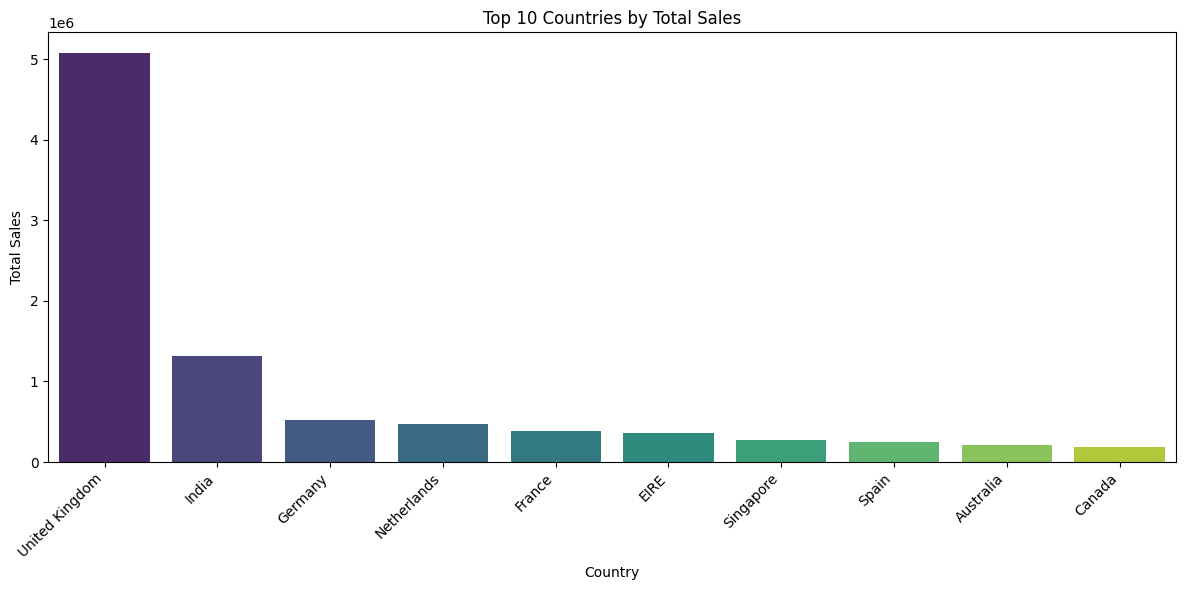

In [56]:
# Visualize top countries by sales
plt.figure(figsize=(12, 6))
sns.barplot(x='Country', y='TotalPrice', data=country_sales.head(10), palette='viridis')
plt.title('Top 10 Countries by Total Sales')
plt.xlabel('Country')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Interpretation: **Top 10 Countries by Total Sales**

This bar chart displays the top 10 countries by total sales revenue. The '**United Kingdom**' significantly leads in sales, followed by 'India', 'Germany', and 'Netherlands', indicating that marketing and sales efforts should primarily focus on these regions.

**Question 2: Which products are sold the most?**

In [60]:
# Calculate total quantity sold per product
product_sales = df.groupby('Description')['Quantity'].sum().reset_index()
product_sales = product_sales.sort_values('Quantity', ascending=False)

print("Top 10 Products Sold by Quantity:")
display(product_sales.head(10))

Top 10 Products Sold by Quantity:


,Description,Quantity
26,USB-C Cable,485
2,Cotton Bedsheet,457
22,Smart Watch Strap,453
15,Notebook Pack,444
8,Gift Wrapping Paper,440
27,Water Bottle,434
23,Sports Socks Pack,432
3,Dark Chocolate Box,429
19,Protein Shaker,428
28,Wireless Mouse,427


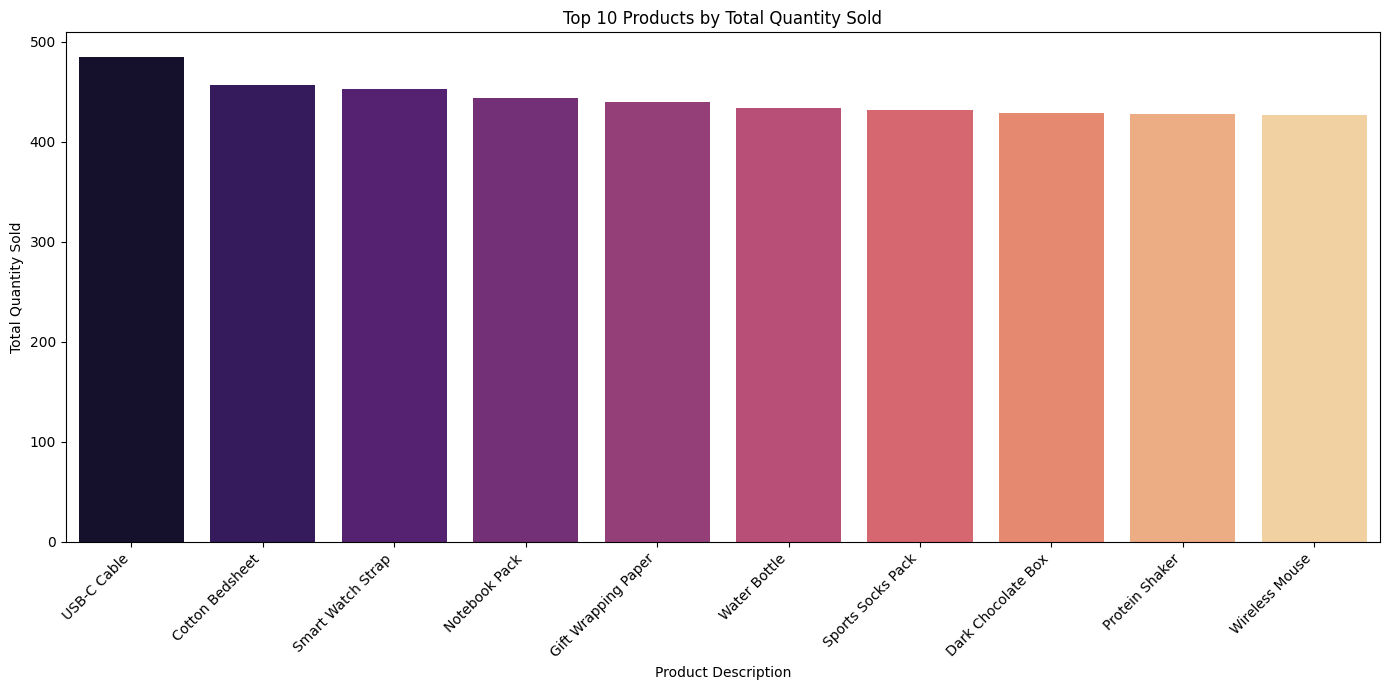

In [61]:
# Visualize top products by quantity sold
plt.figure(figsize=(14, 7))
sns.barplot(x='Description', y='Quantity', data=product_sales.head(10), palette='magma')
plt.title('Top 10 Products by Total Quantity Sold')
plt.xlabel('Product Description')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Interpretation: **Top 10 Products by Total Quantity Sold**
This bar chart shows the top 10 products based on the total quantity sold. '**USB-C Cable**' and '**Cotton Bedsheet**' are among the most frequently purchased items, suggesting high demand for these products.

**Question 3: which products generate the highest revenue?**

In [62]:
# Calculate total revenue per product
product_revenue = df.groupby('Description')['TotalPrice'].sum().reset_index()
product_revenue = product_revenue.sort_values('TotalPrice', ascending=False)

print("Top 10 Products by Total Revenue:")
display(product_revenue.head(10))

Top 10 Products by Total Revenue:


,Description,TotalPrice
0,Bluetooth Speaker,936458.19
20,Running Shoes,882656.10
4,Denim Jacket,725974.85
25,Travel Backpack,592789.30
2,Cotton Bedsheet,592381.23
11,LED Table Lamp,468922.36
9,Hair Care Kit,388105.56
29,Yoga Mat,362532.24
12,Laptop Sleeve,361688.20
7,Face Serum,341787.55


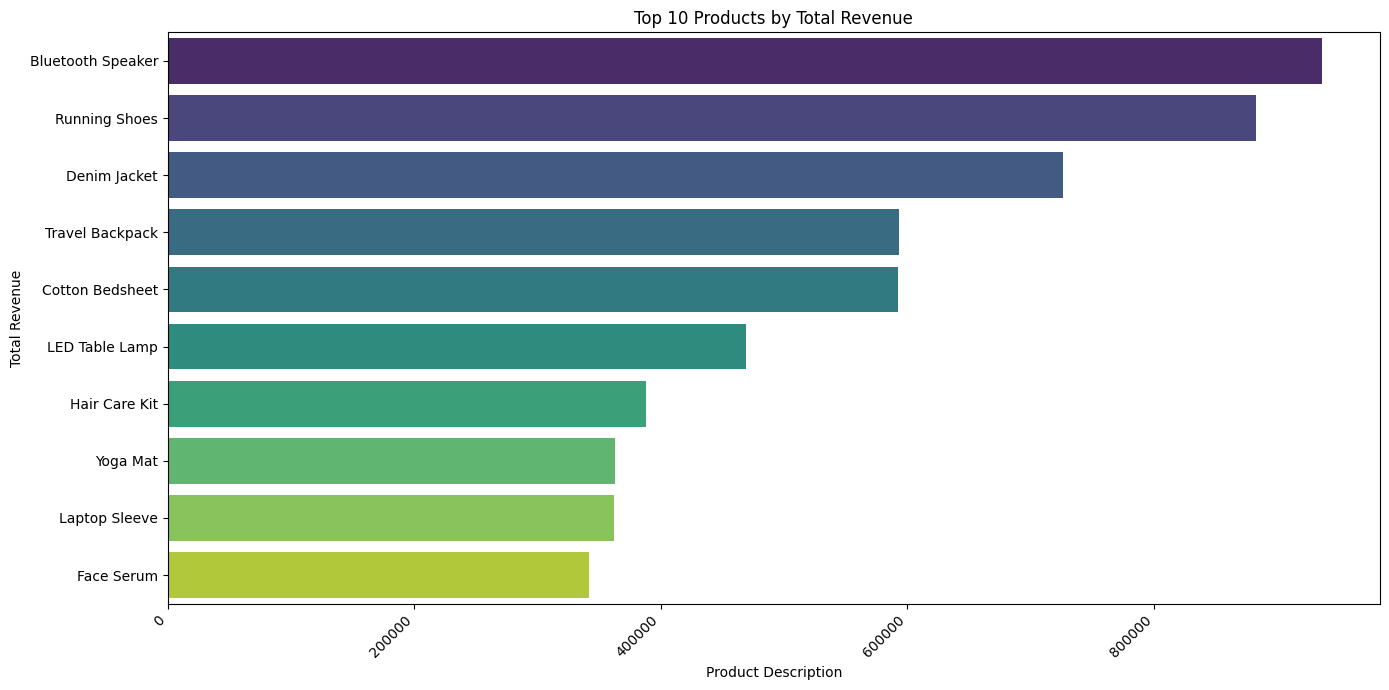

In [63]:
# Visualize top products by total revenue
plt.figure(figsize=(14, 7))
sns.barplot(x='TotalPrice', y='Description', data=product_revenue.head(10), palette='viridis')
plt.title('Top 10 Products by Total Revenue')
plt.xlabel('Product Description')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Interpretation: **Top 10 Products by Total Revenue**

This bar chart illustrates the top 10 products contributing the most to total revenue. '**Bluetooth Speaker**' and '**Running Shoes**' lead in revenue generation, consistent with their high sales quantity, highlighting their importance as cash cows.

**Question 4: What is the distribution of customer purchase frequency?**

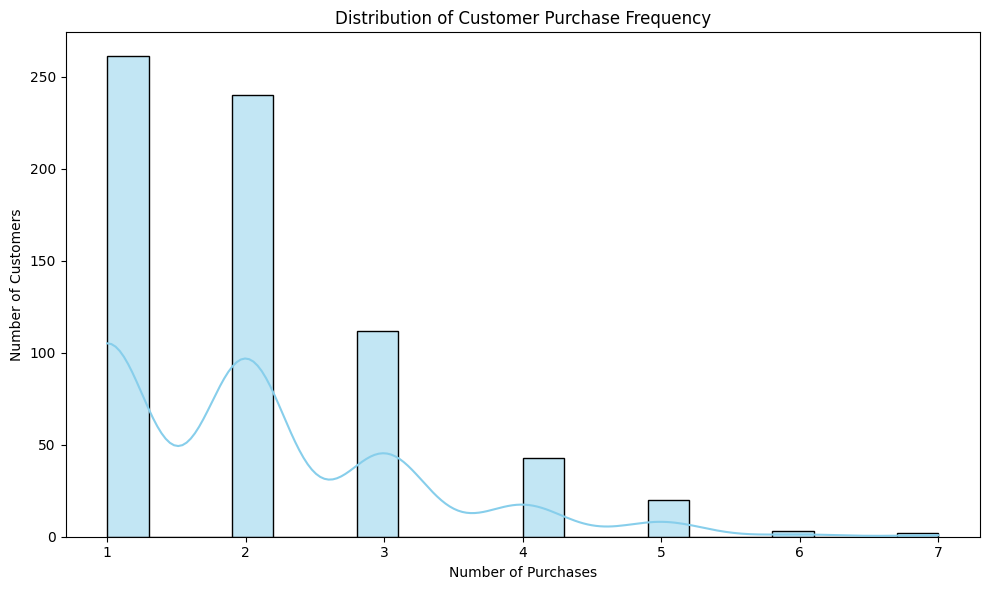

In [65]:
# Visualize the distribution of customer purchase frequency
plt.figure(figsize=(10, 6))
sns.histplot(rfm_table_compact['TotalPurchases'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Customer Purchase Frequency')
plt.xlabel('Number of Purchases')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

Interpretation: **Distribution of Customer Purchase Frequency**

This histogram shows the distribution of customer purchase frequency. **Most customers have a low purchase frequency** (1-2 purchases), with a long tail indicating a small number of highly frequent purchasers. This suggests opportunities for engagement strategies to increase repeat purchases among the majority.

**Question 5: What is the distribution of order value?**

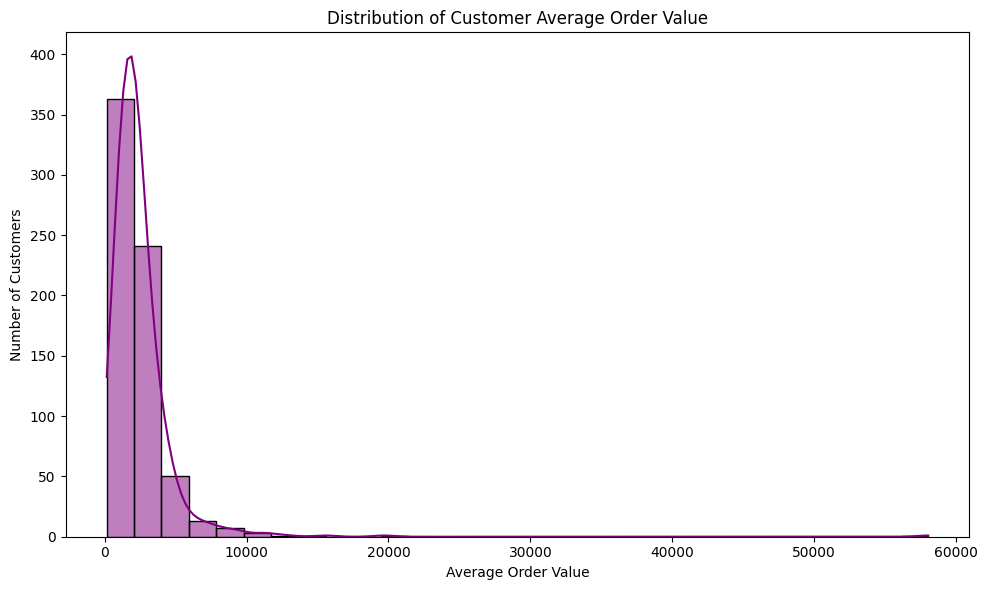

In [66]:
# Visualize the distribution of customer order value (AverageOrderValue)
plt.figure(figsize=(10, 6))
sns.histplot(aov_per_customer['AverageOrderValue'], bins=30, kde=True, color='purple')
plt.title('Distribution of Customer Average Order Value')
plt.xlabel('Average Order Value')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

Interpretation: **Distribution of Customer Average Order Value**

This histogram displays the distribution of customer average order value. The distribution is skewed to the right, indicating that **most customers have a lower average order valu**e, while a few customers make significantly larger average purchases. This pattern points to potential for upselling and cross-selling strategies.

**Question 6: Are there outliers in quantity,price or revenue?**

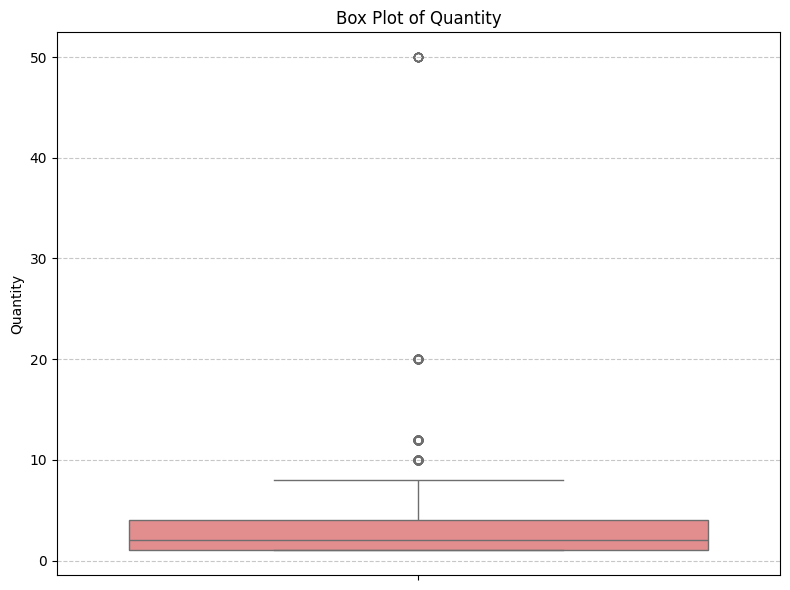

In [72]:
# Box plot for 'Quantity'
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Quantity'], color='lightcoral')
plt.title('Box Plot of Quantity')
plt.ylabel('Quantity')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Interpretation: **Box Plot of Quantity**

This box plot for 'Quantity' reveals the distribution of product quantities per transaction. It clearly shows a **significant number of outliers**, particularly on the higher side, indicating some transactions involve unusually large quantities. These outliers might represent bulk purchases by certain customers or businesses.

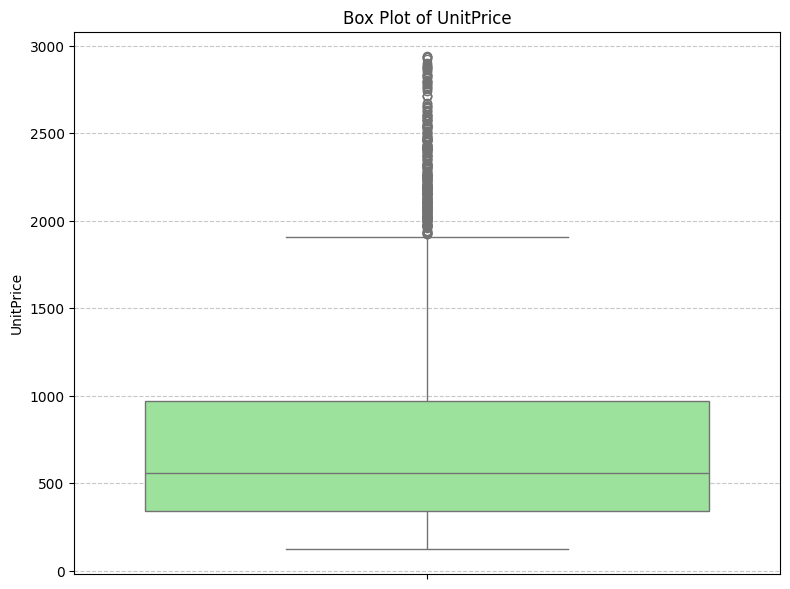

In [73]:
# Box plot for 'UnitPrice'
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['UnitPrice'], color='lightgreen')
plt.title('Box Plot of UnitPrice')
plt.ylabel('UnitPrice')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Interpretation: **Box Plot of UnitPrice**

The box plot for 'UnitPrice' displays the distribution of prices for individual products. Similar to 'Quantity', **there are numerous outliers** in 'UnitPrice', especially on the higher end. This suggests that while most products fall within a certain price range, some high-value items are sold at much higher prices.

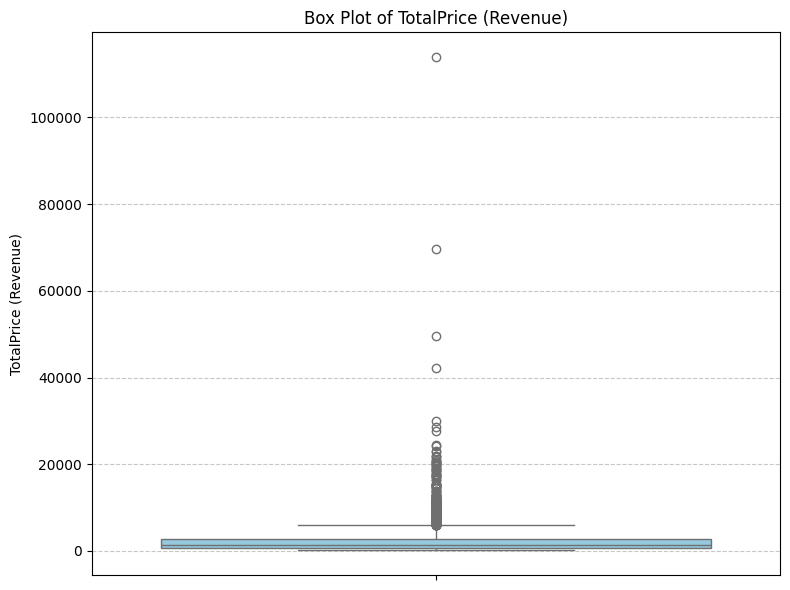

In [74]:
# Box plot for 'TotalPrice' (Revenue)
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['TotalPrice'], color='skyblue')
plt.title('Box Plot of TotalPrice (Revenue)')
plt.ylabel('TotalPrice (Revenue)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Interpretation: **Box Plot of TotalPrice (Revenue)**

This box plot for 'TotalPrice' (Revenue) shows the distribution of total revenue generated per transaction. It also **exhibits many outliers** on the higher side, indicating that a small number of transactions contribute significantly larger amounts of revenue. This aligns with the presence of outliers in both 'Quantity' and 'UnitPrice', as 'TotalPrice' is a product of these two.

**Question 7: which customers appears to be high value customer**

RFM Table with individual R, F, M Scores and combined RFM_Score:


,CustomerID,Recency,TotalPurchases,TotalRevenue,R_Score,F_Score,M_Score,RFM_Score
0,C10001,117,3,22885.81,2,2,4,8
1,C10003,33,1,12061.04,4,1,3,8
2,C10004,40,2,10579.97,4,1,3,8
3,C10005,297,2,14154.57,1,1,3,5
4,C10006,31,3,27389.29,4,2,4,10



Top 10 High-Value Customers based on overall RFM Score:


,CustomerID,Recency,TotalPurchases,TotalRevenue,R_Score,F_Score,M_Score,RFM_Score
656,C10821,22,6,45211.34,4,3,4,11
227,C10280,38,4,19932.81,4,3,4,11
20,C10028,4,5,21765.78,4,3,4,11
628,C10783,25,4,47664.98,4,3,4,11
587,C10738,22,4,24838.99,4,3,4,11
568,C10710,21,4,51428.10,4,3,4,11
489,C10597,8,5,23659.57,4,3,4,11
480,C10587,21,4,22423.31,4,3,4,11
535,C10657,12,4,19219.48,4,3,4,11
81,C10101,31,4,23502.25,4,3,4,11


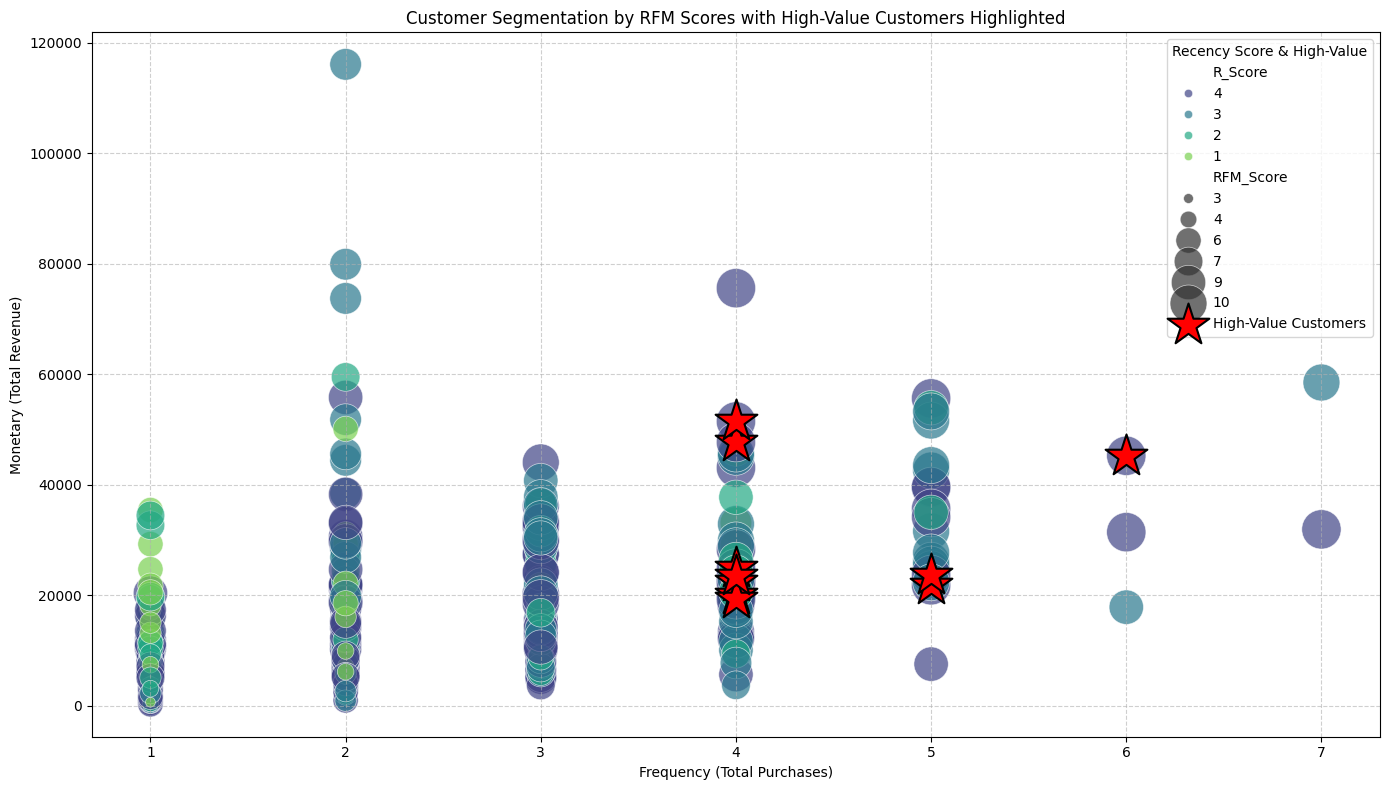

In [77]:
# Assign RFM scores based on quartiles
# Recency: Lower value is better, so we reverse the scoring (higher quartile = lower recency = higher score)
rfm_table_compact['R_Score'] = pd.qcut(rfm_table_compact['Recency'], 4, labels=[4, 3, 2, 1], duplicates='drop')

# Frequency: Higher value is better
# Dynamically determine the number of actual bins qcut can form by getting the bin edges.
# This handles cases where there aren't enough unique values to form 4 distinct quantiles.
_, bins_f_edges = pd.qcut(rfm_table_compact['TotalPurchases'], q=4, duplicates='drop', retbins=True)

# The number of actual bins is one less than the number of bin edges
num_actual_bins_f = len(bins_f_edges) - 1

# Only proceed with assigning F_Score if at least one bin could be formed
if num_actual_bins_f > 0:
    # Create labels dynamically, ensuring they are in ascending order for F_Score (higher frequency = higher score)
    # The labels list length must match the number of actual bins
    labels_f = list(range(1, num_actual_bins_f + 1))

    # Use pd.cut with the determined bins and labels to assign scores
    rfm_table_compact['F_Score'] = pd.cut(
        rfm_table_compact['TotalPurchases'],
        bins=bins_f_edges,
        labels=labels_f,
        include_lowest=True, # Include the minimum value in the first bin
        right=True # Bins are (a, b], as is standard for quantiles
    )
else:
    # If no bins could be formed (e.g., all 'TotalPurchases' values are identical),
    # assign a default score (e.g., 1) to all customers for Frequency.
    rfm_table_compact['F_Score'] = 1

# Monetary: Higher value is better
rfm_table_compact['M_Score'] = pd.qcut(rfm_table_compact['TotalRevenue'], 4, labels=[1, 2, 3, 4], duplicates='drop')

# Calculate the overall RFM score (sum of R, F, M scores)
rfm_table_compact['RFM_Score'] = rfm_table_compact['R_Score'].astype(int) + \
                               rfm_table_compact['F_Score'].astype(int) + \
                               rfm_table_compact['M_Score'].astype(int)

print("RFM Table with individual R, F, M Scores and combined RFM_Score:")
display(rfm_table_compact.head())

# Identify High-Value Customers (e.g., top 10 based on RFM_Score)
high_value_customers = rfm_table_compact.sort_values(by='RFM_Score', ascending=False).head(10)

print("\nTop 10 High-Value Customers based on overall RFM Score:")
display(high_value_customers)

# Visualization: Scatter plot of Frequency vs. Monetary, highlighting top customers
plt.figure(figsize=(14, 8))
sns.scatterplot(
    x='TotalPurchases',
    y='TotalRevenue',
    hue='R_Score', # Color by Recency Score
    size='RFM_Score', # Size by overall RFM Score
    data=rfm_table_compact,
    palette='viridis',
    sizes=(50, 800), # Adjust size range for better visibility
    alpha=0.7,
    edgecolor='w', # Add white edge for better separation
    linewidth=0.5
)

# Highlight high-value customers by plotting them again with a distinct style
sns.scatterplot(
    x='TotalPurchases',
    y='TotalRevenue',
    data=high_value_customers,
    color='red', # Highlight in red
    marker='*', # Use a star marker
    s=1000, # Make the marker larger
    label='High-Value Customers',
    edgecolor='black',
    linewidth=1.5,
    zorder=5 # Ensure these points are drawn on top
)

plt.title('Customer Segmentation by RFM Scores with High-Value Customers Highlighted')
plt.xlabel('Frequency (Total Purchases)')
plt.ylabel('Monetary (Total Revenue)')
plt.legend(title='Recency Score & High-Value')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Interpretation: **Customer Segmentation by RFM Scores with High-Value Customers Highlighted**

This scatter plot visualizes customer segmentation based on Frequency (Total Purchases) and Monetary (Total Revenue), with customers colored by Recency Score and sized by overall RFM Score. **The highlighted red stars represent the identified 'High-Value Customers'**, which tend to cluster in the upper-right quadrant, signifying high frequency and high monetary value. This plot helps in visually identifying and understanding the characteristics of different customer segments, with top customers clearly standing out.

# **CUSTOMER SEGMENTATION USING K MEANS**

**Selecting relevant features for clustering**

In [79]:
# Select RFM features for clustering
rfm_features = rfm_table_compact[['Recency', 'TotalPurchases', 'TotalRevenue']]
display(rfm_features.head())

,Recency,TotalPurchases,TotalRevenue
0,117,3,22885.81
1,33,1,12061.04
2,40,2,10579.97
3,297,2,14154.57
4,31,3,27389.29


**Normalise or scale the data**

In [80]:
# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the RFM features
rfm_scaled = scaler.fit_transform(rfm_features)

# Convert scaled data back to a DataFrame for easier handling
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=rfm_features.columns, index=rfm_features.index)

print("Scaled RFM features:")
display(rfm_scaled_df.head())

Scaled RFM features:


,Recency,TotalPurchases,TotalRevenue
0,-0.080051,0.884554,0.753723
1,-1.020730,-0.935329,-0.107681
2,-0.942340,-0.025388,-0.225540
3,1.935690,-0.025388,0.058916
4,-1.043127,0.884554,1.112097


**Use the elbow method to choose a suitable number of clusters**

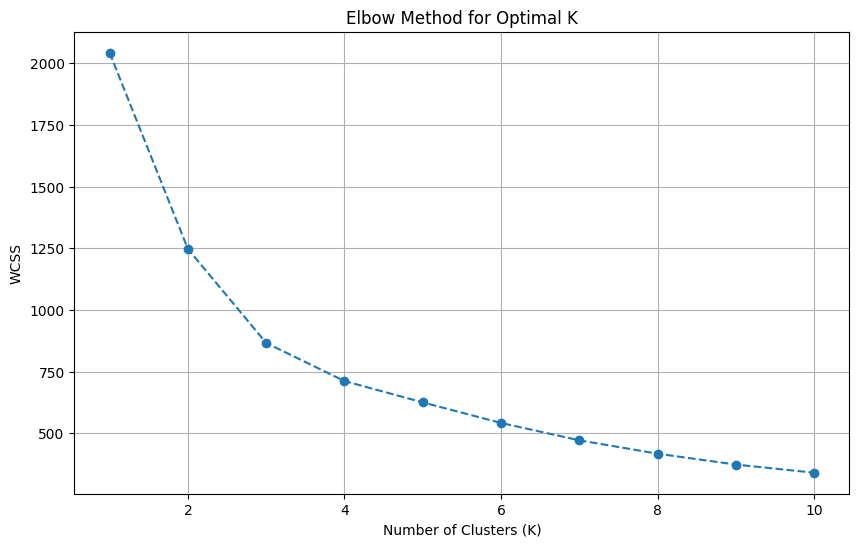

In [81]:
wcss = []
# Test a range of cluster numbers, e.g., from 1 to 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10) # n_init is set to 10 to suppress warning
    kmeans.fit(rfm_scaled_df)
    wcss.append(kmeans.inertia_) # inertia is the WCSS

# Plot the elbow method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

Looking at the elbow plot, the elbow appears to be around k=3 or k=4. let's choose 4 clusters for now. we will train the K-means model with 4 clusters

**Train the K-means model and assign cluster labels to customers**

In [85]:
# Initialize KMeans with the chosen number of clusters (e.g., 4)
k_clusters = 4 # Based on the elbow method
kmeans_model = KMeans(n_clusters=k_clusters, init='k-means++', random_state=42)

# Fit the model and predict clusters
rfm_table_compact['Cluster'] = kmeans_model.fit_predict(rfm_scaled)

print(f"K-Means model trained with {k_clusters} clusters. Cluster labels added to rfm_table.")
display(rfm_table_compact.head())

K-Means model trained with 4 clusters. Cluster labels added to rfm_table.


,CustomerID,Recency,TotalPurchases,TotalRevenue,R_Score,F_Score,M_Score,RFM_Score,RFM_Segment,Cluster
0,C10001,117,3,22885.81,2,2,4,8,Mid-Value Customers,0
1,C10003,33,1,12061.04,4,1,3,8,Mid-Value Customers,3
2,C10004,40,2,10579.97,4,1,3,8,Mid-Value Customers,3
3,C10005,297,2,14154.57,1,1,3,5,Mid-Value Customers,2
4,C10006,31,3,27389.29,4,2,4,10,Top Customers,0


# **Analyse each cluster**

Average RFM values per cluster:


,Cluster,Recency,TotalPurchases,TotalRevenue
0,0,72.055901,2.962733,18482.903851
1,1,75.838710,3.935484,41432.314839
2,2,232.423963,1.382488,8196.505207
3,3,73.883817,1.493776,7518.178382


Number of customers per cluster:


,Cluster,Count
2,0,161
3,1,62
1,2,217
0,3,241


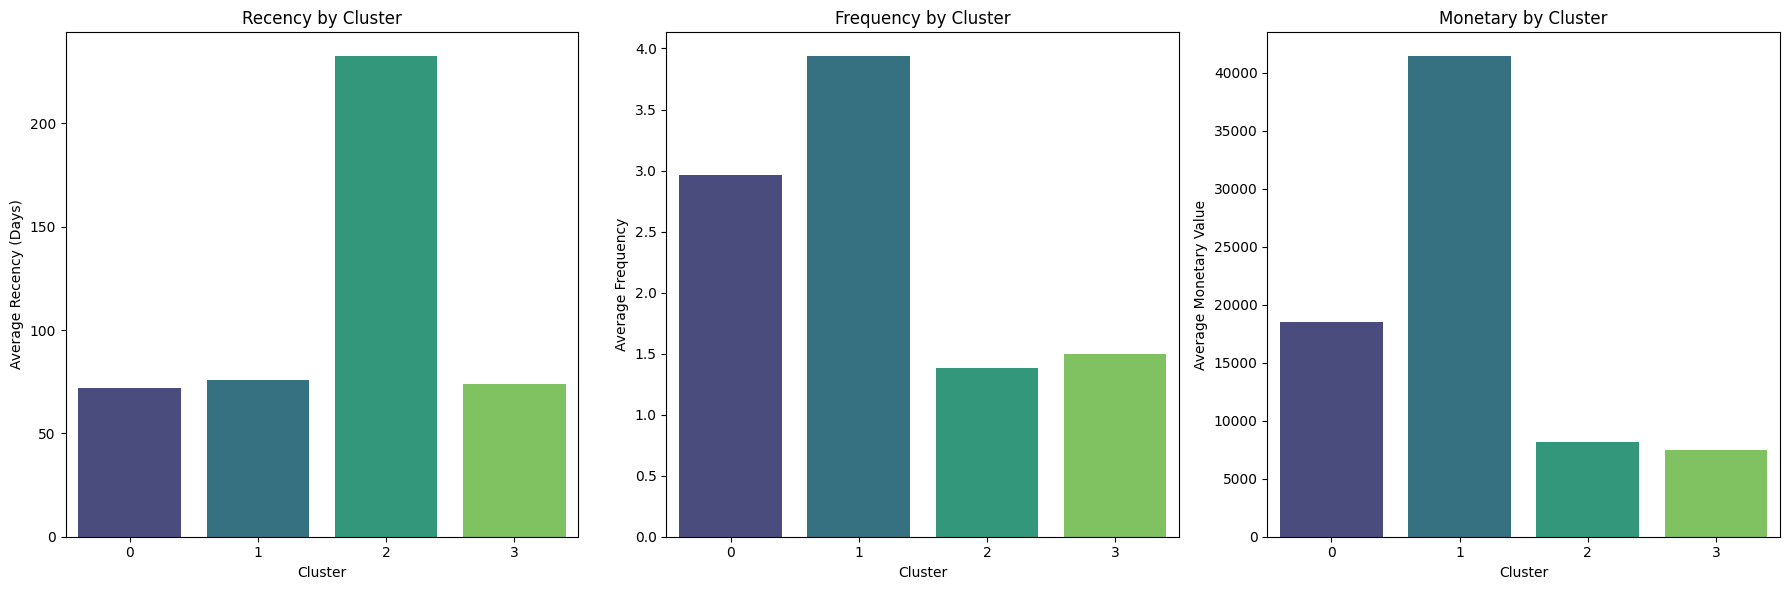

In [90]:
# Calculate the mean of R, F, M for each cluster
cluster_analysis = rfm_table_compact.groupby('Cluster')[['Recency', 'TotalPurchases','TotalRevenue']].mean().reset_index()

print("Average RFM values per cluster:")
display(cluster_analysis)

# Also count the number of customers in each cluster
cluster_counts = rfm_table_compact['Cluster'].value_counts().reset_index()
cluster_counts.columns = ['Cluster', 'Count']

print("Number of customers per cluster:")
display(cluster_counts.sort_values(by='Cluster'))

# Visualize the cluster characteristics
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.barplot(x='Cluster', y='Recency', data=cluster_analysis, ax=axes[0], palette='viridis')
axes[0].set_title('Recency by Cluster')
axes[0].set_ylabel('Average Recency (Days)')

sns.barplot(x='Cluster', y='TotalPurchases', data=cluster_analysis, ax=axes[1], palette='viridis')
axes[1].set_title('Frequency by Cluster')
axes[1].set_ylabel('Average Frequency')

sns.barplot(x='Cluster', y='TotalRevenue', data=cluster_analysis, ax=axes[2], palette='viridis')
axes[2].set_title('Monetary by Cluster')
axes[2].set_ylabel('Average Monetary Value')

plt.tight_layout()
plt.show()

# **K-Means Cluster Interpretation**

Based on the `cluster_analysis` and the RFM metrics, here's an interpretation of each customer segment:

#### **Cluster 0: Promising Customers**
*   **Customer Behavior:** These customers have moderate recency and make a good number of purchases, leading to a respectable total revenue. They are active but not yet in the 'champion' category.
*   **Spending Pattern:** Medium to high spending per customer.
*   **Purchase Frequency:** Moderate frequency, suggesting regular but not hyper-frequent engagement.
*   **Recency Pattern:** Fairly recent purchases, indicating ongoing engagement.
*   **Possible Customer Type:** Promising, Potential Loyalists.
*   **Business Value:** These customers have solid value and strong potential to become Loyal & High-Value customers with targeted nurturing. Strategies should focus on increasing their purchase frequency and average order value.

#### **Cluster 1: Loyal & High-Value Customers (Champions)**
*   **Customer Behavior:** These are your most valuable customers. They purchase frequently and spend the most, and their recent activity indicates strong loyalty.
*   **Spending Pattern:** Very high spending, contributing significantly to overall revenue.
*   **Purchase Frequency:** High frequency of purchases.
*   **Recency Pattern:** Relatively recent purchases, indicating continued engagement.
*   **Possible Customer Type:** Champions, Loyal Customers.
*   **Business Value:** This is the most crucial segment for the business. Focus on retention, loyalty programs, exclusive offers, and encouraging referrals. They are highly profitable and key to sustained growth.

#### **Cluster 2: Churned/Lost Customers**
*   **Customer Behavior:** These customers made purchases a long time ago, and their overall purchase frequency and total spending are very low. They show signs of disengagement.
*   **Spending Pattern:** Very low spending per customer.
*   **Purchase Frequency:** Very low frequency, often just one or two purchases.
*   **Recency Pattern:** Very high recency, meaning it's been a long time since their last purchase.
*   **Possible Customer Type:** Churned, Lost Customers, At-Risk.
*   **Business Value:** Low immediate business value. Strategies could involve win-back campaigns with aggressive discounts or re-engagement offers, but the cost-effectiveness should be considered.

#### **Cluster 3: New/One-Time Shoppers (Potential)**
*   **Customer Behavior:** These customers have purchased recently, but their overall purchase frequency and total revenue are quite low. They might be new customers or those who have made only a single purchase.
*   **Spending Pattern:** Low spending per customer.
*   **Purchase Frequency:** Very low frequency, often just one purchase.
*   **Recency Pattern:** Fairly recent purchases, indicating initial engagement.
*   **Possible Customer Type:** New Customers, One-Time Shoppers, Potential.
*   **Business Value:** This segment has high growth potential. Focus on onboarding, educational content, personalized recommendations, and incentives for a second purchase to move them into more valuable segments.